### **import important libraries**

In [9]:
import pandas as pd
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

from text_processor import TextProcessor

#### **load data**

In [2]:
data = pd.read_csv("F:\Sentiment-Analysis-App\dataset\IMDB Dataset.csv")

<>:1: SyntaxWarning: invalid escape sequence '\S'
<>:1: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Muhammad\AppData\Local\Temp\ipykernel_13116\341679195.py:1: SyntaxWarning: invalid escape sequence '\S'
  data = pd.read_csv("F:\Sentiment-Analysis-App\dataset\IMDB Dataset.csv")


<Axes: xlabel='sentiment', ylabel='count'>

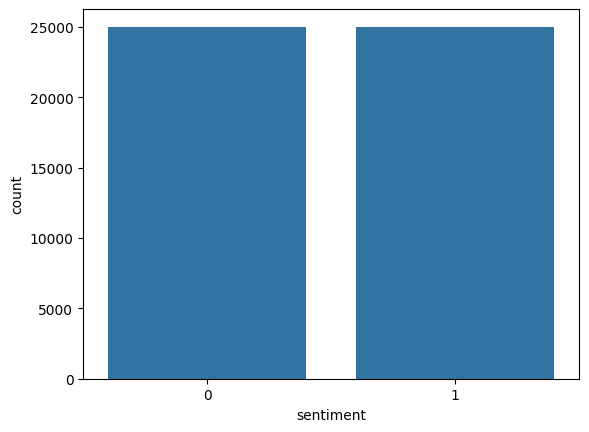

In [10]:
sns.barplot(data.sentiment.value_counts())

#### Apply clean_text Function to questions and answers

In [3]:
data['review'] = data['review'].apply(TextProcessor.clean_text) 
data['sentiment'] = data['sentiment'].map({'positive': 1, 'negative': 0})

#### **split data**

In [4]:
X = data['review']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### **Feature extraction using TF-IDF**

In [5]:
# Define the pipeline
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),  # Unigrams and bigrams
    ('model', LogisticRegression(max_iter=5000, solver='liblinear', C=1.0))
])

# Train the pipeline on the raw text data
pipeline.fit(X_train, y_train)

Pipeline(steps=[('vectorizer',
                 TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
                ('model',
                 LogisticRegression(max_iter=5000, solver='liblinear'))])

##### **evaluate model**

In [6]:
y_pred = pipeline.predict(X_test)
print("Final Optimized Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Final Optimized Model Accuracy: 0.9018

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90      5000
           1       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



#### Save the model and vectorizer into a single file

In [7]:
joblib.dump(pipeline, 'model.pkl')
print("Model and vectorizer saved as 'model.pkl'")

Model and vectorizer saved as 'model.pkl'
